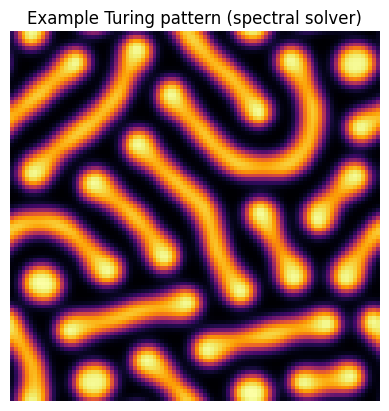

In [24]:
# ============================================================
# Turing Pattern Inversion Dataset Generator (Research-grade)
# Based on: Schnörr & Schnörr (2023), "Learning System Parameters from Turing Patterns"
# Implements semi-implicit spectral solver for Gierer–Meinhardt model
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2, fftfreq
from tqdm import tqdm
import os, time

# ============================================================
# 1. Reaction–Diffusion System (Gierer–Meinhardt)
# ============================================================

def gierer_meinhardt(u, v, a, b, c, gamma, eps=1e-6):
    """Gierer–Meinhardt kinetics with stabilization."""
    v_safe = np.maximum(v, eps)
    du = a - b*u + (u**2)/(v_safe*(1 + c*u**2))
    dv = b*u - v
    return du, dv


# ============================================================
# 2. Semi-implicit spectral solver (fast and stable)
# ============================================================

def simulate_gm_spectral(a, b, c, gamma, s=0.5, n=96, T=4000, dt=1.0):
    """
    Semi-implicit solver for 2D Gierer–Meinhardt model.
    Uses spectral Laplacian (FFT) for diffusion terms.
    """
    # Diffusion coefficients
    Du, Dv = s, s*gamma

    # Initialize concentration fields
    u = 0.5 + 0.05*np.random.randn(n, n)
    v = 0.5 + 0.05*np.random.randn(n, n)

    # Precompute Laplacian operator in Fourier space
    kx = fftfreq(n).reshape(-1, 1)
    ky = fftfreq(n).reshape(1, -1)
    lap = -4 * np.pi**2 * (kx**2 + ky**2)
    Lu = 1.0 / (1 - dt * Du * lap)   # for implicit update of u
    Lv = 1.0 / (1 - dt * Dv * lap)   # for implicit update of v

    # Integrate in time
    n_steps = int(T / dt)
    for _ in range(n_steps):
        du, dv = gierer_meinhardt(u, v, a, b, c, gamma)
        # Semi-implicit step via FFT
        u = np.real(ifft2(fft2(u + dt*du) * Lu))
        v = np.real(ifft2(fft2(v + dt*dv) * Lv))
        # Keep fields bounded
        u = np.clip(u, 0, 2)
        v = np.clip(v, 0, 2)

    return u, v


# ============================================================
# 3. Dataset generation (with chunked saving for large runs)
# ============================================================

def generate_dataset(n_samples=200, n=96, batch_size=100, save_dir="turing_data", seed=0):
    np.random.seed(seed)
    os.makedirs(save_dir, exist_ok=True)
    start = time.time()

    all_params = []
    for batch_start in range(0, n_samples, batch_size):
        batch_end = min(batch_start + batch_size, n_samples)
        batch_patterns = []
        batch_params = []

        for i in tqdm(range(batch_start, batch_end)):
            a = np.random.uniform(0.1, 0.3)
            b = np.random.uniform(0.8, 1.5)
            c = np.random.uniform(0.2, 2.0)
            gamma = np.random.uniform(50, 120)

            u, v = simulate_gm_spectral(a, b, c, gamma, n=n)
            # Skip low-contrast (non-pattern) cases
            if np.std(u) < 0.02:
                continue

            batch_patterns.append(u.astype(np.float32))
            batch_params.append([a, b, c, gamma])

        np.savez_compressed(
            os.path.join(save_dir, f"batch_{batch_start:05d}.npz"),
            patterns=np.array(batch_patterns),
            params=np.array(batch_params)
        )
        all_params.extend(batch_params)
        print(f"Saved batch {batch_start}-{batch_end}")

    print(f"Total time: {(time.time()-start)/60:.1f} min")
    print(f"Approx. {len(all_params)} valid patterns saved to {save_dir}")


# ============================================================
# 4. Visualization
# ============================================================

def show_patterns(patterns, params, n_show=6):
    plt.figure(figsize=(15, 6))
    n_show = min(n_show, len(patterns))
    for i in range(n_show):
        plt.subplot(2, (n_show+1)//2, i+1)
        plt.imshow(patterns[i], cmap='inferno', interpolation='nearest')
        plt.axis('off')
        p = np.round(params[i], 3)
        plt.title(f"a={p[0]}, b={p[1]}\\nc={p[2]}, γ={p[3]}", fontsize=9)
    plt.tight_layout()
    plt.show()


# ============================================================
# 5. Run test
# ============================================================

if __name__ == "__main__":
    # small test run
    u, v = simulate_gm_spectral(0.1, 1.0, 0.5, 80)
    plt.imshow(u, cmap="inferno")
    plt.title("Example Turing pattern (spectral solver)")
    plt.axis("off")
    plt.show()

    # Uncomment for full dataset
    # generate_dataset(n_samples=20000, n=96, batch_size=200)

In [25]:
# Quick dataset preview
generate_dataset(n_samples=10, n=96, batch_size=10, save_dir="turing_data_preview", seed=42)

100%|██████████| 10/10 [00:49<00:00,  4.95s/it]

Saved batch 0-10
Total time: 0.8 min
Approx. 1 valid patterns saved to turing_data_preview


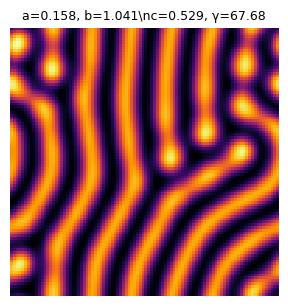

In [26]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("turing_data_preview/batch_00000.npz")
patterns = data['patterns']
params = data['params']

show_patterns(patterns, params, n_show=10)

In [27]:
n_needed = 6
patterns = []
params_list = []

while len(patterns) < n_needed:
    for _ in range(10):  # generate a small batch of 10
        a = np.random.uniform(0.1, 0.3)
        b = np.random.uniform(0.8, 1.5)
        c = np.random.uniform(0.2, 2.0)
        gamma = np.random.uniform(50, 120)
        u, v = simulate_gm_spectral(a, b, c, gamma, n=96, T=4000)
        patterns.append(u)
        params_list.append([a,b,c,gamma])
        if len(patterns) == n_needed:
            break

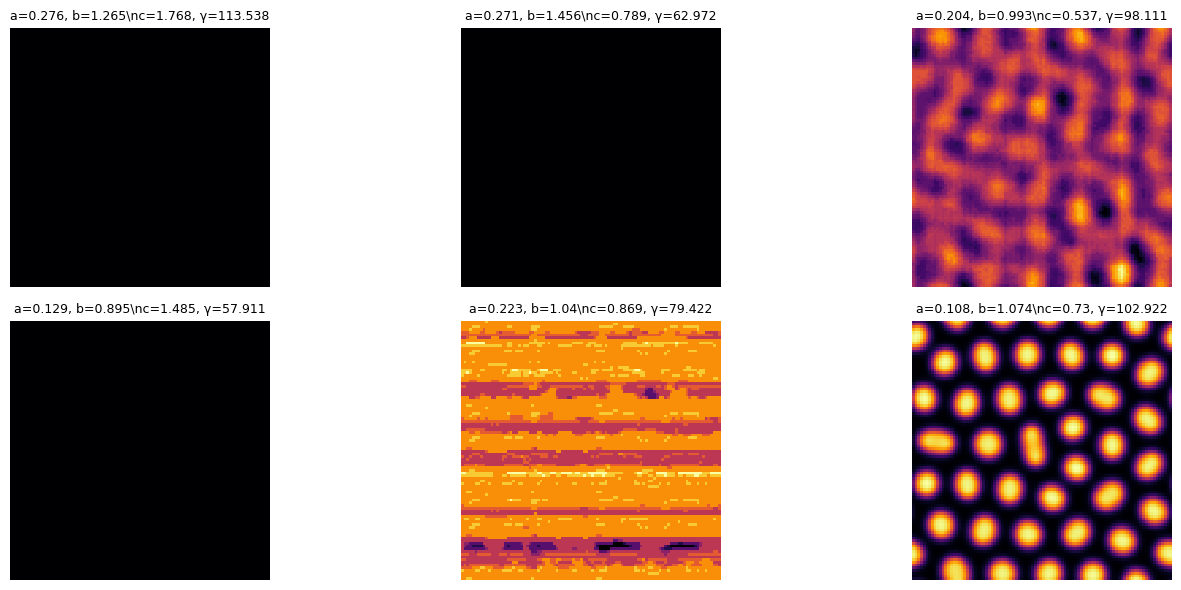

In [28]:
show_patterns(patterns, params_list, n_show=len(patterns))

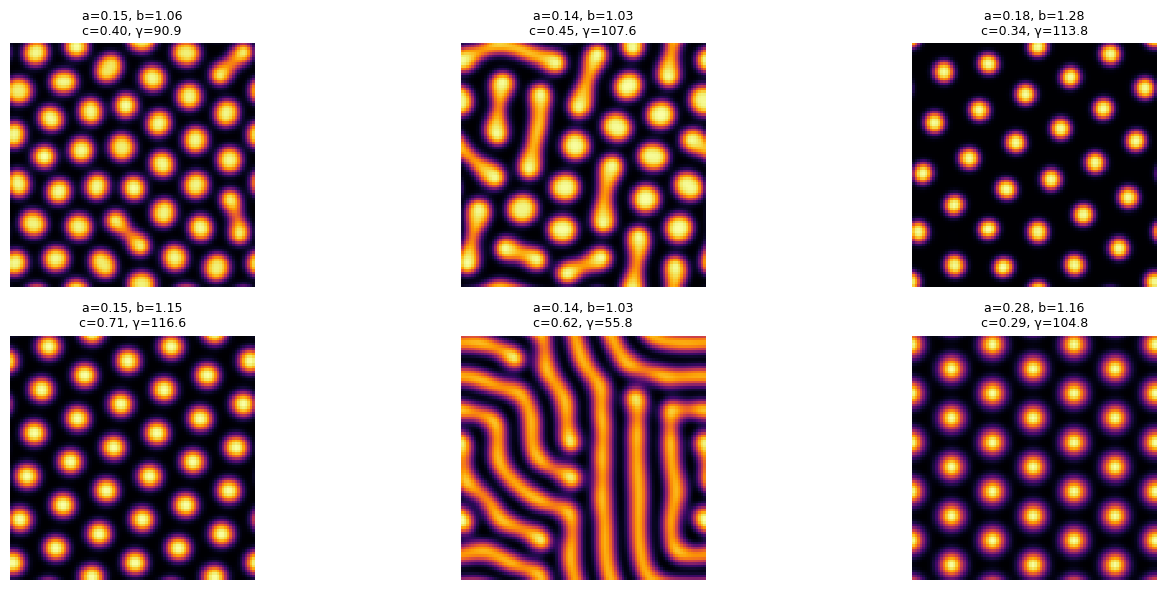

In [29]:
import numpy as np
import matplotlib.pyplot as plt

n_needed = 6
patterns = []
params_list = []

# Parameters likely to produce Turing patterns
a_range = (0.1, 0.3)
b_range = (0.8, 1.5)
c_range = (0.2, 2.0)
gamma_range = (50, 120)
contrast_threshold = 0.01  # only accept patterns with enough contrast

while len(patterns) < n_needed:
    for _ in range(10):  # generate a small batch
        a = np.random.uniform(*a_range)
        b = np.random.uniform(*b_range)
        c = np.random.uniform(*c_range)
        gamma = np.random.uniform(*gamma_range)
        u, v = simulate_gm_spectral(a, b, c, gamma, n=96, T=4000)

        # Check contrast
        if np.std(u) < contrast_threshold:
            continue  # skip almost uniform fields

        # Accept the pattern
        patterns.append(u)
        params_list.append([a, b, c, gamma])
        if len(patterns) == n_needed:
            break

# Visualize
plt.figure(figsize=(15, 6))
for i in range(len(patterns)):
    plt.subplot(2, (len(patterns)+1)//2, i+1)
    plt.imshow(patterns[i], cmap='inferno', interpolation='nearest')
    plt.axis('off')
    p = params_list[i]
    plt.title(f"a={p[0]:.2f}, b={p[1]:.2f}\nc={p[2]:.2f}, γ={p[3]:.1f}", fontsize=9)
plt.tight_layout()
plt.show()

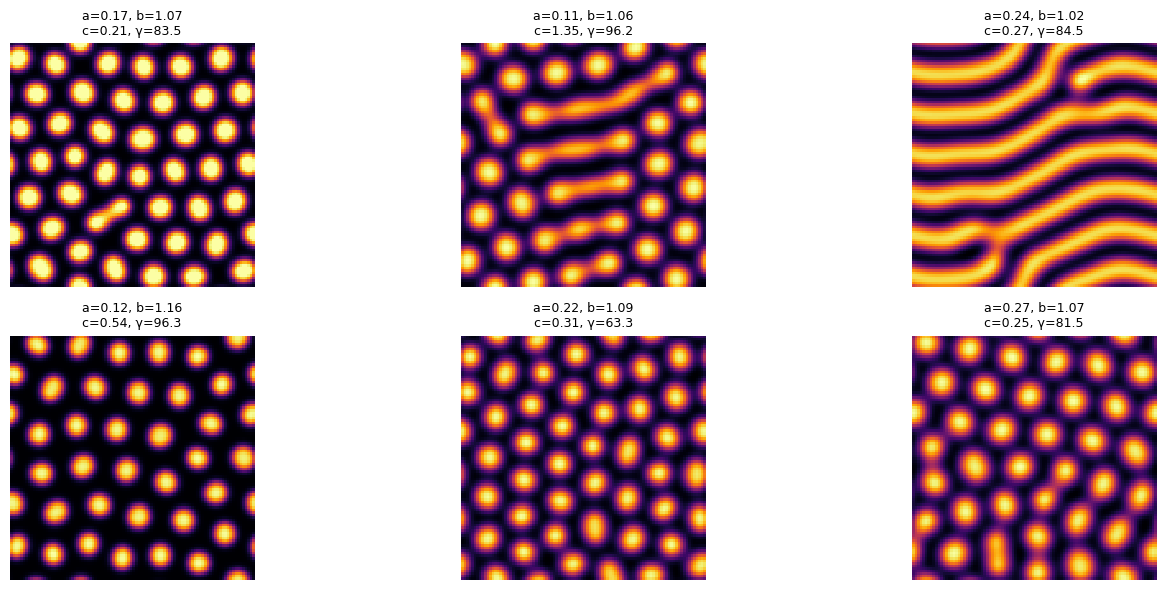

In [31]:
import numpy as np
import matplotlib.pyplot as plt

n_needed = 6
patterns = []
params_list = []

# Parameters likely to produce Turing patterns
a_range = (0.1, 0.3)
b_range = (0.8, 1.5)
c_range = (0.2, 2.0)
gamma_range = (50, 120)
contrast_threshold = 0.01  # only accept patterns with enough contrast

while len(patterns) < n_needed:
    for _ in range(10):  # generate a small batch
        a = np.random.uniform(*a_range)
        b = np.random.uniform(*b_range)
        c = np.random.uniform(*c_range)
        gamma = np.random.uniform(*gamma_range)
        u, v = simulate_gm_spectral(a, b, c, gamma, n=96, T=1200)

        # Check contrast
        if np.std(u) < contrast_threshold:
            continue  # skip almost uniform fields

        # Accept the pattern
        patterns.append(u)
        params_list.append([a, b, c, gamma])
        if len(patterns) == n_needed:
            break

# Visualize
plt.figure(figsize=(15, 6))
for i in range(len(patterns)):
    plt.subplot(2, (len(patterns)+1)//2, i+1)
    plt.imshow(patterns[i], cmap='inferno', interpolation='nearest')
    plt.axis('off')
    p = params_list[i]
    plt.title(f"a={p[0]:.2f}, b={p[1]:.2f}\nc={p[2]:.2f}, γ={p[3]:.1f}", fontsize=9)
plt.tight_layout()
plt.show()